In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "kwill580"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()
if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Assignments/Final Exam"
#os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

2. State the outcome variable and how it was measured.

3. State the independent variables. What lurking variables may be present?

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?

5. State all sets of statistical hypotheses.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.formula.api import mixedlm
from scipy import stats
from scipy.stats import chi2
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns
#Import Data
burritos = pd.read_excel('/content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam/Busters Burritos.xlsx')

## Data Integrity Check ##

print(burritos.info())

## Exploratory Data Analysis ##
## Start with Main Effects ##

## Protein ##

protein_stats = burritos.groupby("Protein")["Satisfaction"].agg(['mean', 'std'])

print(protein_stats)

## Salsa ##

salsa_stats = burritos.groupby("Salsa")["Satisfaction"].agg(['mean', 'std'])

print(salsa_stats)

## Potatoes ##

potatoes_stats = burritos.groupby("Potatoes")["Satisfaction"].agg(['mean', 'std'])

print(potatoes_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Protein       120 non-null    object 
 1   Salsa         120 non-null    object 
 2   Potatoes      120 non-null    object 
 3   Satisfaction  120 non-null    float64
dtypes: float64(1), object(3)
memory usage: 3.9+ KB
None
           mean       std
Protein                  
Bacon    6.8500  0.928467
Chorizo  7.0075  1.167374
Sausage  5.7725  1.052710
           mean       std
Salsa                    
Hot    6.070000  1.116031
Mild   7.016667  1.055762
              mean       std
Potatoes                    
No        6.335000  1.227071
Yes       6.751667  1.105378


In [4]:
## Question 6 Code ##

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

In [5]:
## Question 7 Code ##

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

In [6]:
## Question 8 Code ##

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [7]:
## Question 9 Code ##

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [8]:
## Question 10 Code ##

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [9]:
## Question 11 Code ##

12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.
* The objective of this experiment is to determine if there is a significant difference in sales amount depending on the location of Bruster's Burrito truck, the days it is set up and the marketing stragey.

2. Specify the outcome variable and how it is measured.
* Outcome variable: Sales amount in dollars (continuous vairable).

3. Specify the independent variables. What lurking variables may be present?
* Independent variables: Location (Brewery vs University), Timing (Weekday vs. Weekend), and Marketing (Independent vs. Partnership)  - all are nominal categorical
variables
* Lurking variable: Potential
lurking variables would be local customer's schedule or time constraints and  environmental factors such as temperature outside.

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?
* The advantages of using a fractional design would be cost reduction, fewer runs, and the ability to isolate main effects and low-order interactions with fewer runs. However, the disadvantages include the potential for confounding effects and the need for careful selection of which combinations to test.

5. State the sets of null and alternative hypotheses for this experiment.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [10]:
## Import relevant libraries ##
import pandas as pd
import numpy as np

## Read in the Data ##

sales = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam/Busters Burrito Sales.xlsx")

## Evaluate the Data ##

print(sales.info())
print(sales.head())
## Add Effect Column to sales dataframe ##

sales['Effect'] = np.repeat(["c","b","a","abc"], repeats=6)

print(sales.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   24 non-null     object 
 1   Timing     24 non-null     object 
 2   Marketing  24 non-null     object 
 3   Sales      24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
     Location   Timing    Marketing   Sales
0     Brewery  Weekday  Independent  800.93
1     Brewery  Weekday  Independent  895.44
2     Brewery  Weekday  Independent  728.44
3  University  Weekday  Independent  739.61
4  University  Weekday  Independent  804.20
     Location   Timing    Marketing   Sales Effect
0     Brewery  Weekday  Independent  800.93      c
1     Brewery  Weekday  Independent  895.44      c
2     Brewery  Weekday  Independent  728.44      c
3  University  Weekday  Independent  739.61      c
4  University  Weekday  Independent  804.20      c


     Location         mean         std
0     Brewery  1130.844167  240.497137
1  University   969.116667  226.779048
    Timing         mean         std
0  Weekday   856.971667  139.886119
1  Weekend  1242.989167  150.626558
     Marketing         mean         std
0  Independent   956.325833  213.917393
1  Partnership  1143.635000  242.150011


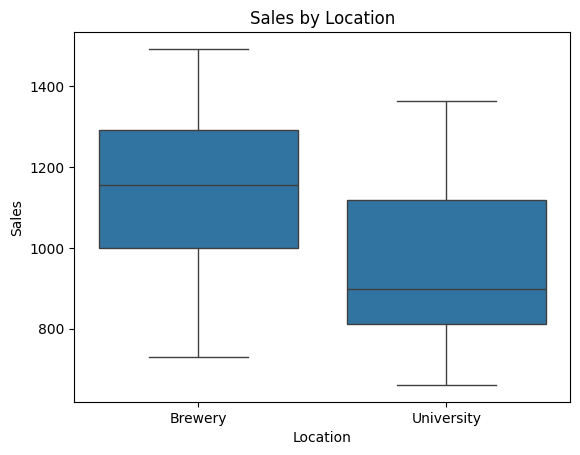

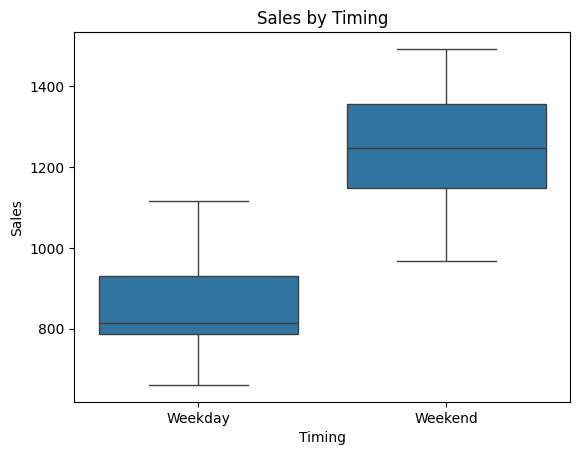

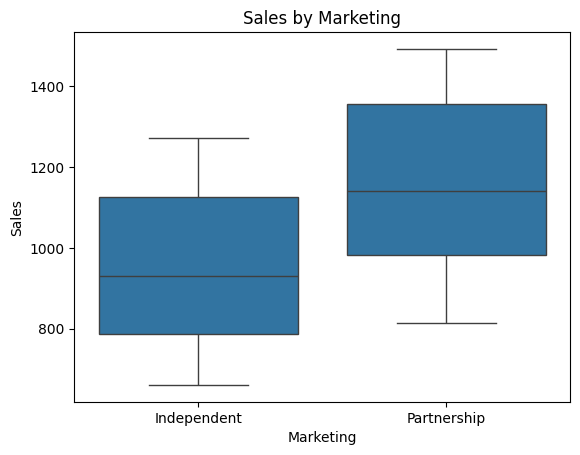

In [11]:
## Calculate Summary Statistics for the Main Effects ##

import seaborn as sns
import matplotlib.pyplot as plt

## Location Effect ##

location_effect = sales.groupby('Location')['Sales'].agg(['mean','std']).reset_index()

print(location_effect)

## Timing Effect ##

timing_effect = sales.groupby('Timing')['Sales'].agg(['mean','std']).reset_index()

print(timing_effect)

## Marketing Effect ##

marketing_effect = sales.groupby('Marketing')['Sales'].agg(['mean','std']).reset_index()

print(marketing_effect)

## Plot Boxplots for Each Factor using seaborn ##

## Location Boxplot ##

sns.boxplot(x='Location', y='Sales', data=sales)
plt.title('Sales by Location')
plt.show()

## Timing Boxplot ##

sns.boxplot(x='Timing', y='Sales', data=sales)
plt.title('Sales by Timing')
plt.show()

## Marketing Boxplot ##
sns.boxplot(x='Marketing', y='Sales', data=sales)
plt.title('Sales by Marketing')
plt.show()

* Looking at the summary statistics, the brewery yields a higher mean sales amount than university as a location. When loooking at timing as a factor, the weekend yields a higher mean sales amount the the weekdays. For the marketing factor, partnership yields a higher mean sales amount than independent. This provides some
support for the alternative hypothesis. Each boxplot presents the gap between each category of independent variables.

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?
* Main Effect A is aliased with the BC interaction:
    $A = A \times I = A \times ABC = A^2BC = BC$
*  We cannot determine if The significant effect is truly due to factor A, the BC interaction, or both, since all main effects are confounded with two-factor interactions.

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

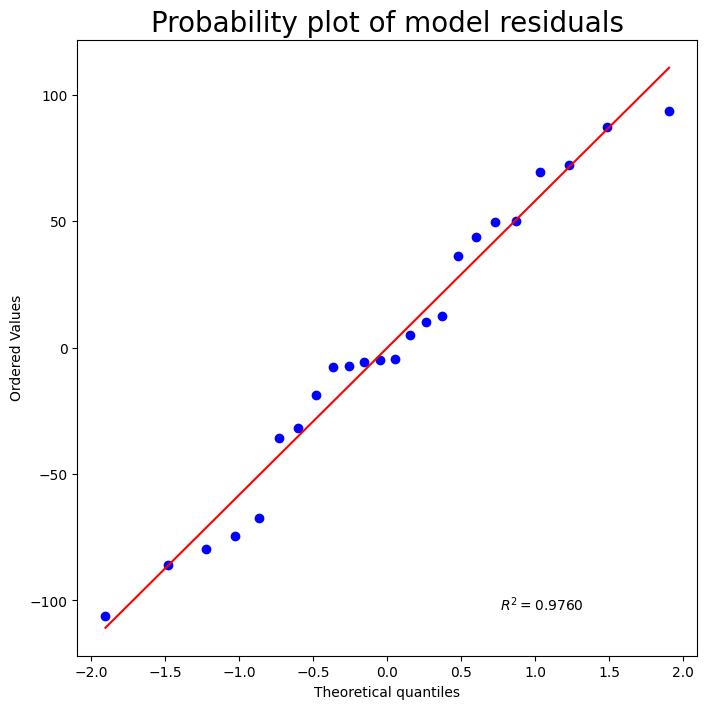

Shapiro-Wilk Test Statistic: 0.9644079966970597
p-value: 0.5331135188378288
Fail to reject the null hypothesis: Residuals are normally distributed.


In [21]:
## First, import ols function ##

from statsmodels.formula.api import ols
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

sales_mod = ols('Sales ~ Location * Timing * Marketing', data=sales).fit()

## Extract Model Residuals ##

sales_residuals = sales_mod.resid

## Generate QQ-plot ##
fig = plt.figure(figsize= (8, 8))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(sales_residuals, plot= plt, rvalue= True)
ax.set_title("Probability plot of model residuals", fontsize= 20)
ax.set
plt.show()

## Run Shapiro-Wilk Test for Normality ##

sales_shapiro_test = stats.shapiro(sales_residuals)
print(f'Shapiro-Wilk Test Statistic: {sales_shapiro_test.statistic}')
print(f'p-value: {sales_shapiro_test.pvalue}')
if sales_shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis: Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis: Residuals are normally distributed.")



* The S-W test statistic's p-value is greater than our traditionally used 0.05 significance level, indicating that we fail to reject the null hypothesis of normality. The data support the assumption of normality.
* The Q-Q plot shows that the residuals closely follow the diagonal line with little deviation, indicating that the normality assumption is satisfied.

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

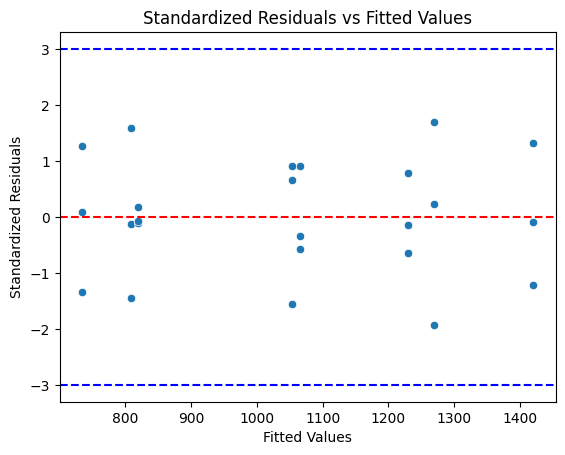

F-statistic: 1.4032247161349127
F p-value: 0.2704341243418291
Fail to reject the null hypothesis: No heteroscedasticity detected. Constant variance assumption holds.


In [22]:
## Generate Scatterplot of Standardized Residuals vs Fitted Values ##

sales_standard_res = sales_mod.get_influence().resid_studentized_internal
sales_fitted_vals = sales_mod.fittedvalues

sns.scatterplot(x=sales_fitted_vals,y=sales_standard_res)
plt.axhline(y=0, color='r', linestyle='--')
plt.axhline(y=3, color='b', linestyle='--')
plt.axhline(y=-3, color='b', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Standardized Residuals')
plt.title('Standardized Residuals vs Fitted Values')
plt.show()
## Perform Breusch-Pagan Test for Homoscedasticity ##

sales_bp_test = het_breuschpagan(sales_residuals, sales_mod.model.exog)

## Extract F-statistic ##

sales_f_statistic = sales_bp_test[2]

## Extract its P-Value ##

sales_f_p_value = sales_bp_test[3]

print(f"F-statistic: {sales_f_statistic}")
print(f"F p-value: {sales_f_p_value}")
if sales_f_p_value < 0.05:
    print("Reject the null hypothesis: Heteroscedasticity detected. Constant variance assumption violated.")
else:
    print("Fail to reject the null hypothesis: No heteroscedasticity detected. Constant variance assumption holds.")


* The fitted vs. residual scatterplot has evidence of constant variance. There are no points are greater than +3 or less than -3. There are no obvious outliers in the data. The points seem randomly spread about the horizontal line of 0, indicating that 0 serves as a reasonable estimate for the mean of the residuals. There is not a systematic pattern in the scatterplot.

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [25]:
## Print the ANOVA table ##

anova_table = sm.stats.anova_lm(sales_mod, typ=1)
print(anova_table)
## Add Significance Column ##
anova_table['Significance'] = np.where(anova_table['PR(>F)'] < 0.05, 'Significant', 'Not Significant')
## Filter to only main effects and two-way interactions ##

                             df         sum_sq        mean_sq           F  \
Location                    1.0  156934.705538  156934.705538   34.468059   
Timing                      1.0  894057.061837  894057.061837  196.364540   
Marketing                   1.0  210508.343504  210508.343504   46.234604   
Location:Timing             1.0      18.744338      18.744338    0.004117   
Location:Marketing          1.0    8170.767037    8170.767037    1.794571   
Timing:Marketing            1.0    1612.284337    1612.284337    0.354111   
Location:Timing:Marketing   1.0   14727.746704   14727.746704    3.234701   
Residual                   16.0   72848.758600    4553.047413         NaN   

                                 PR(>F)  
Location                   2.366486e-05  
Timing                     2.110888e-10  
Marketing                  4.268887e-06  
Location:Timing            9.496353e-01  
Location:Marketing         1.990886e-01  
Timing:Marketing           5.601179e-01  
Location:Tim

* All of the main effects are statistically siginificant, due to the p-values being less than the 0.05 threshold. These results support the alternative hypothesis.

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [26]:
## Group the Data by the Effect column and pivot from long to wide ##

df = (sales.groupby("Effect", as_index=False)["Sales"].mean())

df = df.pivot_table(index=None, columns='Effect', values='Sales').reset_index(drop=True)

## Extract factor columns for easier use ##

a   = df['a']
b   = df['b']
c   = df['c']
abc = df['abc']

## Compute factor estimates ##

df2 = pd.DataFrame({
    "A": 0.5 * (a - b - c + abc),
    "B": 0.5 * (-a + b - c + abc),
    "C": 0.5 * (-a - b + c + abc)
})

print(df)
print(df2)


Effect       a      abc            b           c
0       942.43  1344.84  1141.138333  771.513333
            A         B        C
0  187.309167  386.0175  16.3925


* As Location goes from the - level of Brewery to the + level of University, we expect an increase of $16.39.

* As marketing goes from the - level of independence to the + level of partnership, we expect an increase of $187.31.

* As timinng goes from the - level of weekday to the + level of weekend, we expect an increase of $386.02.
* Timing seems more importrant become it has the biggest jump in mean sale amount.

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [16]:
## Calculate Partial Eta Squared for Each Factor ##

## Load pingouin ##
!pip install pingouin
import pingouin as pg

## Fit ANOVA with pingouin ##

mod2 = pg.anova(data=sales, dv='Sales', between=['Location','Timing','Marketing'], detailed=True)

print(mod2[["Source","np2"]][:3])



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.9 MB/s eta 0:00:00
      Source       np2
0   Location  0.682968
1     Timing  0.924658
2  Marketing  0.742908


* The main effect of Location accounts for 68.3% of variance in the response variable. Timing accounts for 92.47% of variance in the response variable. The main effect  Marketing accounts for 74.29% of the variance in the response variable.
* Timing seems to be more important because it explains most of the variance.

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?
* In this experiment, we were analyzing the impact of location, timing and marketing on sales amount for Buster's Burritos. We found significant main effects, incidating all three factors play important roles in sale amounts. To maximize sale amounts, I would go to the brewery on the weekends using partnership marketing. As for limitations, I would consider the small-scale of runs completed. In the future I would increase the run amount and consider environmental factors as well as product prices that could influence the sales amount.

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?
* We have to separate the main effect from two-factor interactions. It is important to de-alias the main effects to get a clear understanding if it produces a statistical difference on its own, rather than another factor attached to it, influencing any differences. De-aliasing may not always be possible if the design did not include all possible combinations of factor levels,  making it complicated to distinguish between the effects of different factors.

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?
* This is good practice to be able to identify characteristics of an experiment to know what kind of experiment it is, what formulas you may need, and how to approach it. Breaking down the characteristics makes the overall project more digestible.

3. What is the difference between a fixed effect and a random effect?
* A fixed effect is a factor whose levels are specifically chosen and are the direct interest. A random effect is a factor whose levels are randomly selected from
other possible levels.

4. What is the most important thing you learned in this class?
* One of the most important things I learned in this class is result interpretation matters. I may be able to present the visuals but I need to work on putting my results into words.